In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Python_Analytics/CSV

sales_data = pd.read_csv("sales_data_updated.csv")
print(sales_data)


Mounted at /content/drive
/content/drive/MyDrive/Python_Analytics/CSV
       order_date      time  aging  customer_id gender device_type  \
0      2018-01-01  10:11:40    5.0        29317   Male         Web   
1      2018-01-01  22:30:44    7.0        42270   Male         Web   
2      2018-01-01  21:55:31   10.0        14563   Male         Web   
3      2018-01-01  13:57:15    9.0        58601   Male         Web   
4      2018-01-01  15:17:41    2.0        48342   Male         Web   
...           ...       ...    ...          ...    ...         ...   
51285  2018-12-30  16:20:22    5.0        88891   Male         Web   
51286  2018-12-30  11:52:02    7.0        74259   Male         Web   
51287  2018-12-30  15:06:46    5.0        62596   Male         Web   
51288  2018-12-30  15:36:49    1.0        77349   Male         Web   
51289  2018-12-30  13:49:02    7.0        79637   Male         Web   

      customer_login_type    product_category                 product  sales  \
0        

In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_date           51290 non-null  object 
 1   time                 51290 non-null  object 
 2   aging                51289 non-null  float64
 3   customer_id          51290 non-null  int64  
 4   gender               51290 non-null  object 
 5   device_type          51290 non-null  object 
 6   customer_login_type  51290 non-null  object 
 7   product_category     51290 non-null  object 
 8   product              51290 non-null  object 
 9   sales                51289 non-null  float64
 10  quantity             51288 non-null  float64
 11  discount             51289 non-null  float64
 12  profit               51290 non-null  float64
 13  shipping_cost        51289 non-null  float64
 14  order_priority       51288 non-null  object 
 15  payment_method       51290 non-null 

In [ ]:
sales_data["profit"].describe()

,profit
count,51290.000000
mean,70.407226
std,48.729488
min,0.500000
25%,24.900000
50%,59.900000
75%,118.400000
max,167.500000


In [ ]:
sales_data["device_type"].value_counts()

,count
device_type,
Web,47632
Mobile,3658


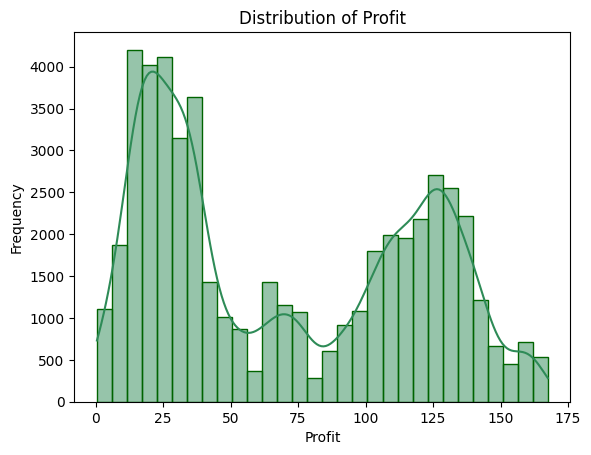

In [ ]:
sns.histplot(
    data=sales_data,
    x="profit",
    bins=30,
    kde=True,
     color="seagreen",
    edgecolor="darkgreen"
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


Найчастіше трапляється невеликий прибуток, але також є окрема група замовлень із значно вищим прибутком.Це може свідчити про наявність різних сегментів товарів або типів продажів.

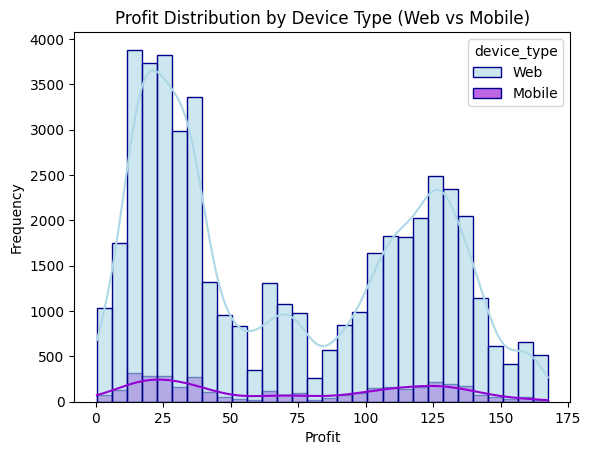

In [ ]:
sns.histplot(
    data=sales_data,
    x="profit",
    hue="device_type",
    bins=30,
    kde=True,
     palette=["lightblue", "darkviolet"],
    edgecolor="darkblue",
    alpha=0.6
)

plt.title("Profit Distribution by Device Type (Web vs Mobile)")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()



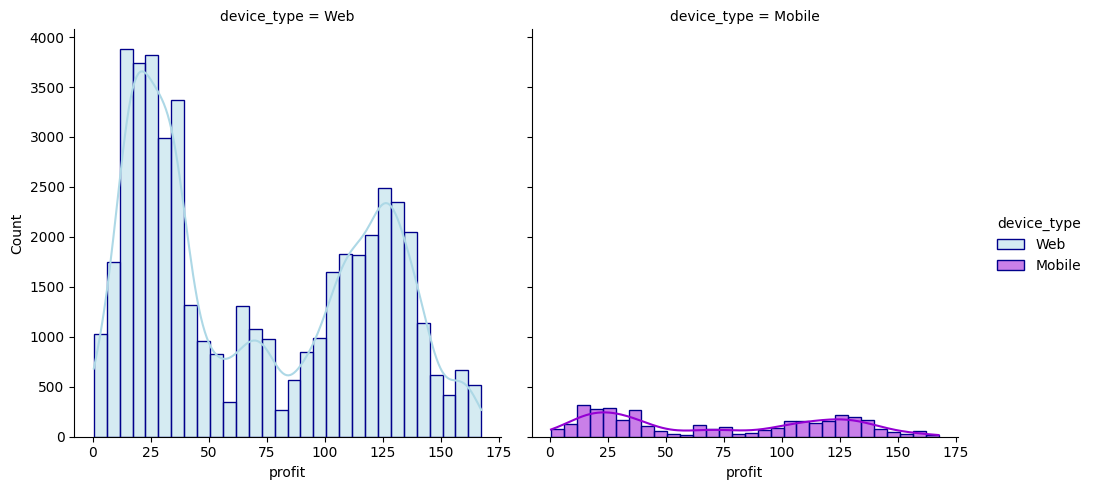

In [ ]:
palette = {
    "Web": "lightblue",
    "Mobile": "darkviolet"
}

sns.displot(
    data=sales_data,
    x="profit",
    col="device_type",
    hue="device_type",
    bins=30,
    kde=True,
    palette=palette,
    edgecolor="darkblue"
)



In [ ]:
sales_data['order_date'].dtype

dtype('O')

In [ ]:
sales_data["order_date"] = pd.to_datetime(sales_data["order_date"])
sales_data['order_date']


,order_date
0,2018-01-01
1,2018-01-01
2,2018-01-01
3,2018-01-01
4,2018-01-01
...,...
51285,2018-12-30
51286,2018-12-30
51287,2018-12-30
51288,2018-12-30


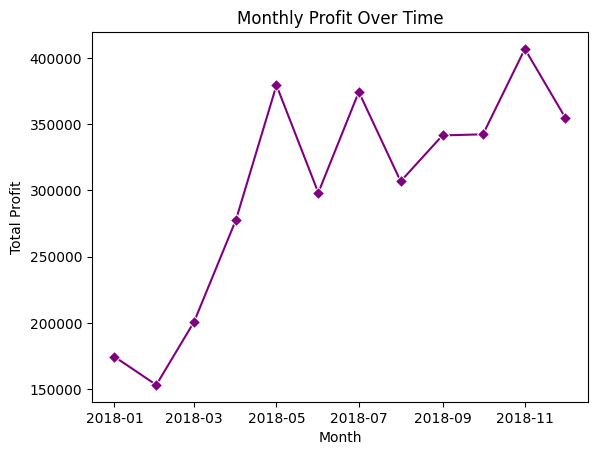

In [ ]:
monthly_profit = (
    sales_data
    .groupby(sales_data["order_date"].dt.to_period("M"))["profit"]
    .sum()
    .reset_index()
)

monthly_profit["order_date"] = monthly_profit["order_date"].dt.to_timestamp()

sns.lineplot(
    data=monthly_profit,
    x="order_date",
    y="profit",
    color="purple",
    marker="D"
)

plt.title("Monthly Profit Over Time")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.show()


Продажі зростають протягом року, але не рівно: є місяці зі спадом і місяці з різким підйомом. Найкращі результати — ближче до кінця року.

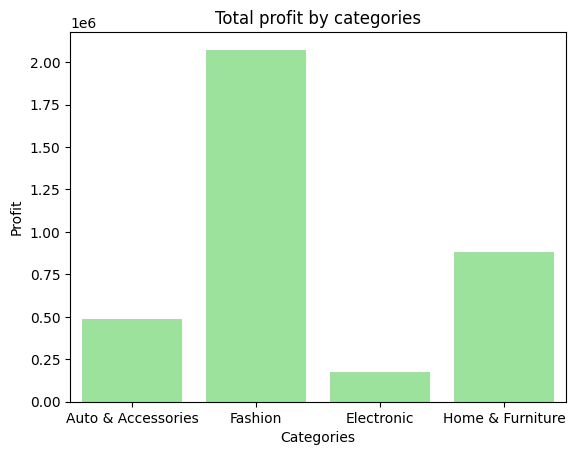

In [ ]:
sns.barplot(
    data=sales_data,
    x="product_category",
    y="profit",
    estimator=sum,
    color="lightgreen",
    errorbar=("ci", False))
plt.title("Total profit by categories")
plt.xlabel("Categories")
plt.ylabel("Profit")
plt.show()

Найбільш прибутковими є товари категорії Fashion,а товари категорії Electronic приносять найменший прибуток.

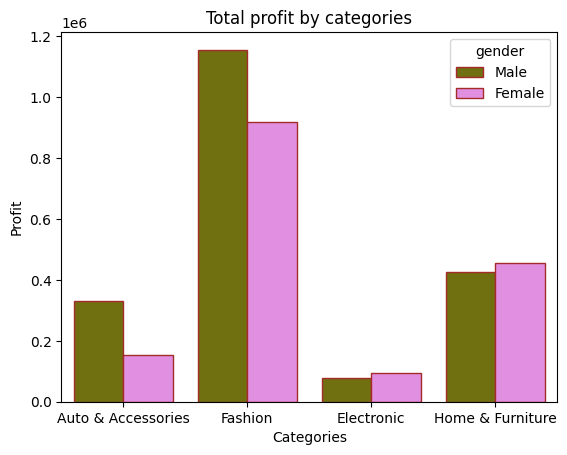

In [ ]:
sns.barplot(
    data=sales_data,
    x="product_category",
    y="profit",
    hue="gender",
    estimator=sum,
    palette=["olive","violet"],
     edgecolor="brown",
    errorbar=("ci", False))
plt.title("Total profit by categories")
plt.xlabel("Categories")
plt.ylabel("Profit")
plt.show()

Гендерні відмінності у прибутку є категорієзалежними: у fashion-орієнтованих та автомобільних товарах домінують чоловіки, тоді як у товарах для дому жінки відіграють більш значущу роль.